<a href="https://colab.research.google.com/github/RobertDS-45/Money_Remmitence_analysis/blob/main/Bot_Money_remmitence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Assuming the user uploads 'Money_Remittance_transactions_2025.csv'
# You can then read it into a pandas DataFrame
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(fn)
    display(df.head())


Saving Money_Remittance_transactions_2025.csv to Money_Remittance_transactions_2025.csv
User uploaded file "Money_Remittance_transactions_2025.csv"


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
0,Bnk-001,1/31/2025,1,Western Union,"3,745","2,207,540,409",573,"273,899,340"
1,Bnk-001,1/31/2025,2,MoneyGram,"1,941","1,351,849,159",166,"116,292,545"
2,Bnk-001,1/31/2025,3,Travelex,273,"1,071,463,474",22,"108,098,083"
3,Bnk-001,1/31/2025,4,UBA Africash,169,"71,548,144",16,"8,833,937"
4,Bnk-001,1/31/2025,5,Coinstar,0,0,0,0


In [ ]:
df.tail()

,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
5035,Bnk-042,12/31/2025,6,Express Money,0,0,0,0
5036,Bnk-042,12/31/2025,7,World Remit,0,0,0,0
5037,Bnk-042,12/31/2025,8,Tanzania Postal Services Inter state,0,0,0,0
5038,Bnk-042,12/31/2025,9,Diaspora Data through Swift,0,0,0,0
5039,Bnk-042,12/31/2025,10,Other Remitance company(s),0,0,0,0


In [ ]:
df.describe()

,DESCRIPTIONNO,OUTFLOW_VOLUME
count,5040.000000,5040.000000
mean,5.500000,11.724603
std,2.872566,57.637492
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.500000,0.000000
75%,8.000000,0.000000
max,10.000000,934.000000


In [ ]:
df.columns

Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=[12,6]

In [ ]:
print("stage 1.1: Loading and cleaning raw data...")
df=pd.read_csv('Money_Remittance_transactions_2025.csv')
df.columns

stage 1.1: Loading and cleaning raw data...


Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
# fixing header typo
df =df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

In [ ]:
# clean string formating
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
  df[col]= df[col].astype(str).str.replace(',', '', regex=True)
  df[col] = pd.to_numeric(df[col],errors='coerce').fillna(0)

# standadize data format and parse reporting month
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'],errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)

# create a composite total turnover feature
df['TOTAL_VALUE'] = df['INFLOW_VOLUME'] + df['OUTFLOW_VALUE']
print(f"Data succefully cleaned. shape: {df.shape}")

Data succefully cleaned. shape: (5040, 10)



 Stage 1.2: Generating Visualization for analysis...


/tmp/ipykernel_3762/1478084774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)


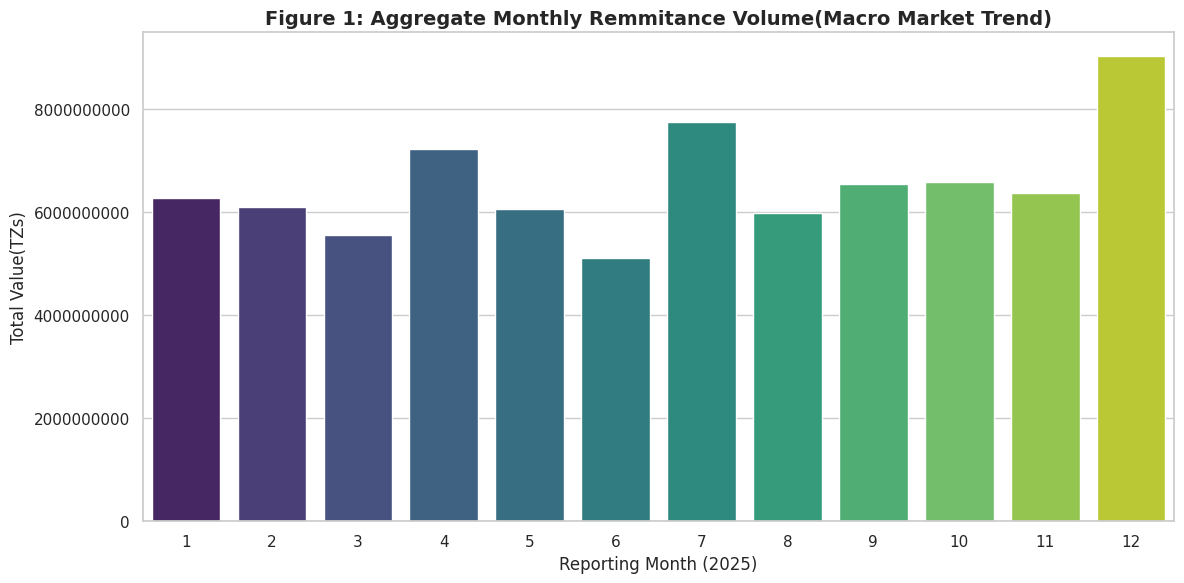

In [ ]:
# 1.2 VISUAL DATA EXPLORATION (EDA)
print("\n Stage 1.2: Generating Visualization for analysis...")
# plot A: Market seasonality chek (total Macro Value by Month)
monthly_market = df.groupby('MONTH')['TOTAL_VALUE'].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)
plt.title('Figure 1: Aggregate Monthly Remmitance Volume(Macro Market Trend)',fontsize=14,fontweight='bold')
plt.xlabel('Reporting Month (2025)',fontsize=12)
plt.ylabel('Total Value(TZs)',fontsize=12)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.savefig('eda_market_seasonality.png',dpi=300)
plt.show()

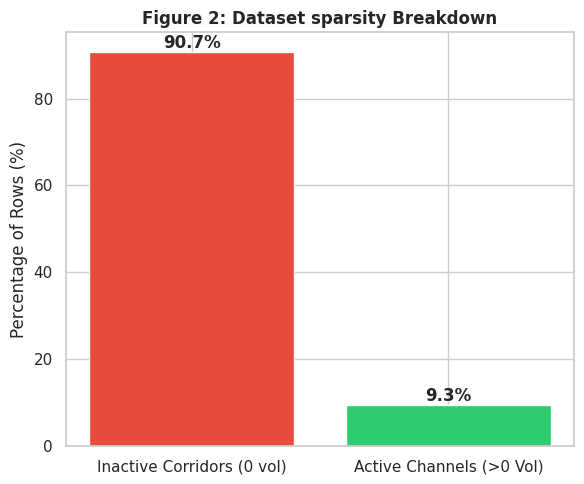

In [16]:
from matplotlib import colors
# PLOT B the sparsity profile (Visualizing the ocean of zero)
sparsity_check = (df['TOTAL_VALUE'] == 0).value_counts(normalize=True)*100

plt.figure(figsize=(6,5))
plt.bar(['Inactive Corridors (0 vol)','Active Channels (>0 Vol)'],sparsity_check.values,color=['#e74c3c','#2ecc71'])
plt.title('Figure 2: Dataset sparsity Breakdown', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Rows (%)',fontsize=12)
for i, val in enumerate(sparsity_check.values):
  plt.text(i,val + 1, f"{val:.1f}%", ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sparsity_check.png',dpi=300)
plt.show()

In [20]:
# 2.1:ENTER-ENTITY OPERATIONAL RATIOS
print("stage 2: Engineering internalTransactinal ratios...")

# Avarage Transaction values per inflow/outflow to look for hyper-inflation transfers
df['INFLOW_AVG_VAL']= np.where(df['INFLOW_VOLUME'] > 0, df['INFLOW_VALUE'] / df['INFLOW_VOLUME'],0)
df['OUTFLOW_AVG_VAL'] = np.where(df['OUTFLOW_VOLUME'] >0, df['OUTFLOW_VALUE'] / df['OUTFLOW_VOLUME'],0)

# Net liquidity gap within the rporting period
df['NET_FLOW_VALUE'] = df['INFLOW_VALUE'] - df['OUTFLOW_VALUE']

# establish the hurdles flag: 1 for active entity relatioships, 0 for structural zeros
df['IS_ACTIVE'] = np.where(df['TOTAL_VALUE'] > 0,1,0)

# STAGE 2: MONTHLY MARKET SHARE &PEER-GROUP NORMALIZATION
print('Stage 2.2 : computing peer Z-score to neutralize Macro seasonality...')

# step A: compute the total market valume per individual month to creat seasonal baselines
monthly_market_totals = df.groupby('MONTH')['TOTAL_VALUE'].transform('sum')

# step B: Compute the axact market  share a bank-oparator combination holds in that specific month
df['MONTHLY_MARKET_SHARE']=np.where(monthly_market_totals > 0, df['TOTAL_VALUE'] / monthly_market_totals,0)

# step C:  Group by month and compute peer grup mean and standard deviation for active stream
# we filter out zeros during statical window scaling so inactive corridors do not distortthe variance
active_mask = df['IS_ACTIVE'] == 1
df['MONTHLY_VALUE_ZSCORE'] = 0.0 # default initialization for inactive channels
if active_mask.any():
  means = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('mean')
  stds = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0,1)
  # apply standard normalization
  df.loc[active_mask,'MONTHLY_VALUE_ZSCORE'] = (df.loc[active_mask,'TOTAL_VALUE'] - means) / stds

df.head()


stage 2: Engineering internalTransactinal ratios...
Stage 2.2 : computing peer Z-score to neutralize Macro seasonality...


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INFLOW_AVG_VAL,OUTFLOW_AVG_VAL,NET_FLOW_VALUE,IS_ACTIVE,MONTHLY_MARKET_SHARE,MONTHLY_VALUE_ZSCORE
0,Bnk-001,2025-01-31,1,Western Union,3745,2207540409,573,273899340,1,273903085,5.894634e+05,4.780093e+05,1933641069,1,0.043607,0.791256
1,Bnk-001,2025-01-31,2,MoneyGram,1941,1351849159,166,116292545,1,116294486,6.964705e+05,7.005575e+05,1235556614,1,0.018515,-0.313861
2,Bnk-001,2025-01-31,3,Travelex,273,1071463474,22,108098083,1,108098356,3.924775e+06,4.913549e+06,963365391,1,0.017210,-0.371330
3,Bnk-001,2025-01-31,4,UBA Africash,169,71548144,16,8833937,1,8834106,4.233618e+05,5.521211e+05,62714207,1,0.001406,-1.067349
4,Bnk-001,2025-01-31,5,Coinstar,0,0,0,0,1,0,0.000000e+00,0.000000e+00,0,0,0.000000,0.000000


In [23]:
df.describe()

,REPORTINGDATE,DESCRIPTIONNO,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INFLOW_AVG_VAL,OUTFLOW_AVG_VAL,NET_FLOW_VALUE,IS_ACTIVE,MONTHLY_MARKET_SHARE,MONTHLY_VALUE_ZSCORE
count,5040,5040.000000,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5.040000e+03,5.040000e+03,5.040000e+03,5040.000000,5040.000000,5.040000e+03
mean,2025-07-15 22:00:00,5.500000,87.569444,9.453491e+07,11.724603,1.558992e+07,6.500000,1.559001e+07,2.524435e+05,3.462505e+05,7.894498e+07,0.092857,0.002381,-2.544261e-18
min,2025-01-31 00:00:00,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-1.072536e+00
25%,2025-04-22 12:00:00,3.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,3.750000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
50%,2025-07-15 12:00:00,5.500000,0.000000,0.000000e+00,0.000000,0.000000e+00,6.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
75%,2025-10-07 18:00:00,8.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,9.250000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
max,2025-12-31 00:00:00,10.000000,5676.000000,6.407443e+09,934.000000,1.313219e+09,12.000000,1.313220e+09,1.197251e+07,1.771022e+07,5.094225e+09,1.000000,0.157541,4.620655e+00
std,NaN,2.872566,408.443759,4.257508e+08,57.637492,7.346364e+07,3.452395,7.346387e+07,1.338563e+06,1.899270e+06,3.609371e+08,0.290261,0.010995,3.008224e-01


In [29]:
# STAGE 2.3: ENCODE CATEGORICAL ENTITIES FOR SUPERVISED LEARNING
print("stage 2.3: Encoding Bank & Vendor categories...")
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

stage 2.3: Encoding Bank & Vendor categories...


In [32]:
le_institution = LabelEncoder()
df['INSTITUTION_ENCODED']=le_institution.fit_transform(df['INSTITUTIONCODE'])
le_company = LabelEncoder()
df['COMPANY_ENCODED'] = le_company.fit_transform(df['COMPANY'])

print("\n---- Feature Engineerin Complete ----")
print(df[['MONTH','TOTAL_VALUE','MONTHLY_MARKET_SHARE','MONTHLY_VALUE_ZSCORE','IS_ACTIVE']].head(10))


---- Feature Engineerin Complete ----
   MONTH  TOTAL_VALUE  MONTHLY_MARKET_SHARE  MONTHLY_VALUE_ZSCORE  IS_ACTIVE
0      1    273903085              0.043607              0.791256          1
1      1    116294486              0.018515             -0.313861          1
2      1    108098356              0.017210             -0.371330          1
3      1      8834106              0.001406             -1.067349          1
4      1            0              0.000000              0.000000          0
5      1            0              0.000000              0.000000          0
6      1     76240938              0.012138             -0.594707          1
7      1            0              0.000000              0.000000          0
8      1    458913959              0.073062              2.088511          1
9      1            0              0.000000              0.000000          0
